# Random Forest — Hyperparameter Tuning

This notebook documents the second Random Forest iteration.

The model uses the top four features identified in the previous iteration and applies hyperparameter search to evaluate whether a simpler model can maintain performance.

> **Data availability:** The original project datasets are not included in this public repository. Place the processed input files in `../data/` using the filenames referenced below.


## Load and Merge Product and Store Data


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from pathlib import Path

DATA_DIR = Path("../data")

df1 = pd.read_excel(DATA_DIR / "products_ML.xlsx")
df2 = pd.read_excel(DATA_DIR / "cleaned_store.xlsx")


In [ ]:
df = pd.merge(df1, df2, on='idstore', how='left')

## Model Development


Para esta iteracao decidimos continuar o trabalho anterior, usando apenas o top 4 de features por importancia. Decidimos tambem procurar qual o melhor conjunto de hiperparametros para o nosso algoritmo, fazendo um random search seguido de grid search.

In [ ]:
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.inspection import permutation_importance

# =========================================================
# STEP 1: Split do Dataset
# =========================================================

train_raw, test_raw = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['sold']
)

print(f"Training rows: {len(train_raw)} | Testing rows: {len(test_raw)}")


# =========================================================
# STEP 2: STRATIFIED 5-FOLD CROSS-VALIDATION
# =========================================================
features = [
    'Margin (%)', 'new_pvp', 'Profit (€)', 'days_until_expiration'
]

X_train = train_raw[features]
y_train = train_raw['sold']

X_test = test_raw[features]
y_test = test_raw['sold']

# =========================================================
# STEP 3 - RANDOMIZED SEARCH
# =========================================================
print("\n" + "="*50)
print("STAGE 1: RANDOMIZED SEARCH")
print("="*50)

param_dist = {
    'n_estimators': [100, 200, 500, 1000],
    'min_samples_leaf': [10, 20, 50],
}
rf_base = RandomForestClassifier(random_state=42, n_jobs=2)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_random_params = random_search.best_params_
print(f"Melhores Parametros Randomized Search:\n{best_random_params}")


Training rows: 119995 | Testing rows: 29999

STAGE 1: RANDOMIZED SEARCH (MEMORY-SAFE)
Best parameters from Randomized Search:
{'n_estimators': 500, 'min_samples_leaf': 10}

STAGE 2: GRID SEARCH (FOCUSED & LIGHTWEIGHT)


"\nparam_grid = {\n   # 'n_estimators': [best_random_params['n_estimators']],\n    #'max_depth': [\n        # best_random_params['max_depth'] - 2,\n        #best_random_params['max_depth'],\n        best_random_params['max_depth'] + 2\n    ],\n    #'min_samples_leaf': [\n        best_random_params['min_samples_leaf'],\n        best_random_params['min_samples_leaf'] + 10\n    ],\n    #'min_samples_split': [best_random_params['min_samples_split']],\n    #'max_features': [best_random_params['max_features']]\n}"

In [ ]:

param_dist = {
    'n_estimators': [ 400, 500, 600],
    'min_samples_leaf': [8, 10, 15],
}

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_dist,
    scoring='roc_auc',
    cv=3,
    n_jobs=2
)

grid_search.fit(X_train, y_train)

final_rf_model = grid_search.best_estimator_
print(f"Melhores parametros depois do Grid Search:\n{grid_search.best_params_}")


# =========================================================
# STEP 4: Avaliacao
# =========================================================
y_pred = final_rf_model.predict(X_test)
y_proba = final_rf_model.predict_proba(X_test)[:, 1]

print("\n=== CLASSIFICATION REPORT (TEST SET) ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")



Best parameters after Grid Search:
{'min_samples_leaf': 8, 'n_estimators': 400}

=== CLASSIFICATION REPORT (TEST SET) ===
              precision    recall  f1-score   support

           0       0.63      0.61      0.62     13902
           1       0.67      0.69      0.68     16097

    accuracy                           0.66     29999
   macro avg       0.65      0.65      0.65     29999
weighted avg       0.65      0.66      0.65     29999

ROC-AUC Score: 0.7040



## Model Evaluation


We compared the test-set results with the training set again to assess model stability. The results were very similar.


In [ ]:
y_train_pred = final_rf_model.predict(X_train)
y_train_proba = final_rf_model.predict_proba(X_train)[:, 1]

print("\n=== CLASSIFICATION REPORT (TREINO) ===")
print(classification_report(y_train, y_train_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_train, y_train_proba):.4f}\n")




=== CLASSIFICATION REPORT (TRAIN SET) ===
              precision    recall  f1-score   support

           0       0.63      0.61      0.62     55610
           1       0.67      0.69      0.68     64385

    accuracy                           0.65    119995
   macro avg       0.65      0.65      0.65    119995
weighted avg       0.65      0.65      0.65    119995

ROC-AUC Score: 0.7051



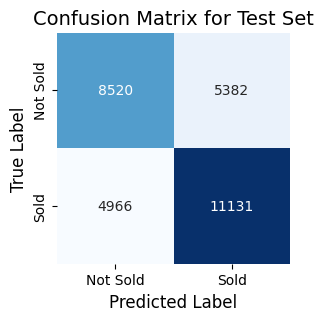

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(3, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Sold', 'Sold'], yticklabels=['Not Sold', 'Sold'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix for Test Set', fontsize=14)
plt.show()

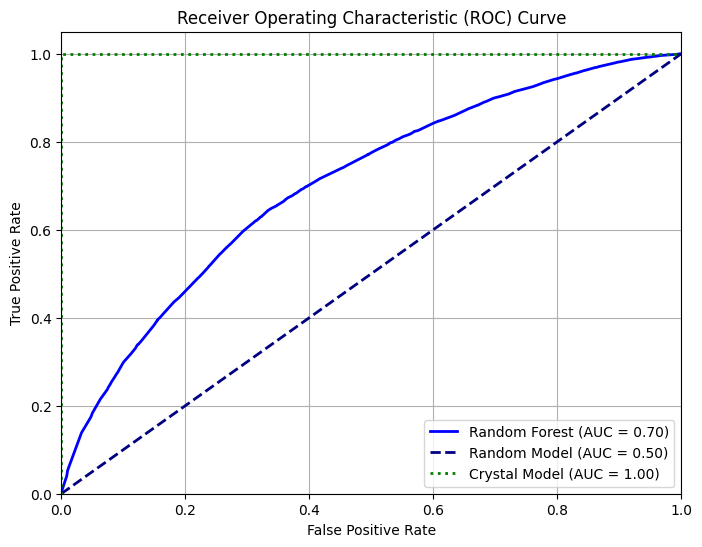

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve for the Random Forest model
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))

# Plot the Random Forest ROC curve
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {auc_rf:.2f})')

# Plot the random model (diagonal line)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Model (AUC = 0.50)')

# Plot the "crystal" (perfect) model
plt.plot([0, 0, 1], [0, 1, 1], color='green', lw=2, linestyle=':', label='Crystal Model (AUC = 1.00)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Conclusion


Hyperparameter tuning allowed us to achieve a similar score using fewer features than in the previous iteration. In the next iteration, we returned to the broader feature set and adjusted the hyperparameters again.
